# Out-of-Distribution Generalisation for Poverty Mapping

**Course:** Machine Learning — Summer 2026
**Instructor:** Prof. Iftikhar Ahmed
**Team Members:** [Add names + matriculation numbers]
**Date:** [Add presentation date]

---

This notebook presents a complete machine learning workflow for predicting poverty (asset wealth index) from satellite imagery, under a real distribution shift between training and test domains, using the PovertyMap-WILDS benchmark.

## 1. Problem Statement

- Remote-sensing models for poverty mapping must transfer across regions where economic and visual patterns differ — this is a **distribution shift** problem.
- We use the **PovertyMap-WILDS** dataset, where each satellite image is paired with an asset wealth index derived from household surveys.
- **Core question:** Can a model trained on one type of region (urban) accurately predict wealth in a different, unseen type of region (rural) — and can we make predictions more *equitable* across these subgroups, not just accurate on average?
- We treat this as a **supervised regression** problem: predict a continuous wealth score from an 8-channel satellite image.
- We compare three approaches of increasing access to information:
  1. **ERM** — a standard image-only baseline
  2. **IRM** — a distribution-robust, image-only method
  3. **ConvNeXt + Metadata** — an image *and* domain-metadata model, included as a contrasting reference point rather than a direct competitor (see Section 5.3)
- We evaluate not only overall accuracy but **worst-group performance**, because a model that is accurate on average but fails on one subgroup is a fairness and reliability risk in real humanitarian deployment.

## 2. Dataset

**Source:** PovertyMap-WILDS (Yeh et al., 2020), distributed via the [WILDS benchmark](https://wilds.stanford.edu/datasets/)

**Files used:** loaded automatically through the `wilds` Python package — no manual file handling required.

- **Input (x):** 8-channel satellite image, 224×224 pixels
  - Channels: Coastal, Blue, Green, Red, Near-Infrared, SWIR-1, SWIR-2, Nighttime Lights
- **Label (y):** continuous asset wealth index (real-valued, from Demographic and Health Survey data)
- **Domain metadata:** each sample is tagged with a domain id (0 or 1) and an urban/rural indicator
- **Splits:**
  - Train: 9,797 samples — **100% urban**
  - Validation: 3,909 samples — **100% rural**
  - Test: 3,963 samples — **100% rural**
- **No subset sampling was needed** — full dataset was used for all splits.
- **Key EDA finding:** the OOD shift in this dataset is **urban → rural**, not country-to-country as initially assumed from the project brief. This was discovered only after manually inspecting the metadata fields, confirming the instruction to "not assume the dataset directly fits the project just because it is listed with the title."
- **Label shift confirmed:** train mean wealth = 0.123, test mean wealth = -0.054 — rural areas are genuinely poorer on average, not just visually different. This label shift is directly relevant to Section 5.3 below.

In [ ]:
# Install dependencies (skip if already installed in this environment)
# !pip install wilds torch torchvision scipy matplotlib --quiet

import numpy as np
# ── Install all required packages ──
!pip install wilds torch torchvision scipy -q
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights, convnext_tiny
from scipy.stats import pearsonr
from wilds import get_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.6 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# If running on Colab, mount Google Drive to access saved models/figures
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PATH = "/content/drive/MyDrive/Machine_Learning_Uni_Project/"
    ON_COLAB = True
except ImportError:
    DRIVE_PATH = "./"
    ON_COLAB = False

print(f"Running on Colab: {ON_COLAB}")
print(f"Asset path: {DRIVE_PATH}")

Mounted at /content/drive
Running on Colab: True
Asset path: /content/drive/MyDrive/Machine_Learning_Uni_Project/


### 2.1 Exploratory Data Analysis (pre-computed)

EDA was performed separately to inspect dataset size, label distribution, sample images across all 8 channels, urban/rural split, and per-domain wealth statistics. The figure below is loaded directly rather than regenerated live, since it requires looping through the full dataset to extract per-sample metadata (a few minutes of compute) — this follows the project guidance to "keep a copy of important outputs and figures needed for the demonstration."

**Key findings from EDA:**
- Wealth index ranges from -1.23 to 2.68
- Training set is 100% urban, validation/test are 100% rural — confirming the real distribution shift
- Nighttime light intensity is the strongest visual proxy for wealth (poor areas ≈ 0 intensity, wealthy areas ≈ 3.7 mean intensity)
- Two domains (0 and 1) appear across all splits; Domain 0 is poorer on average than Domain 1

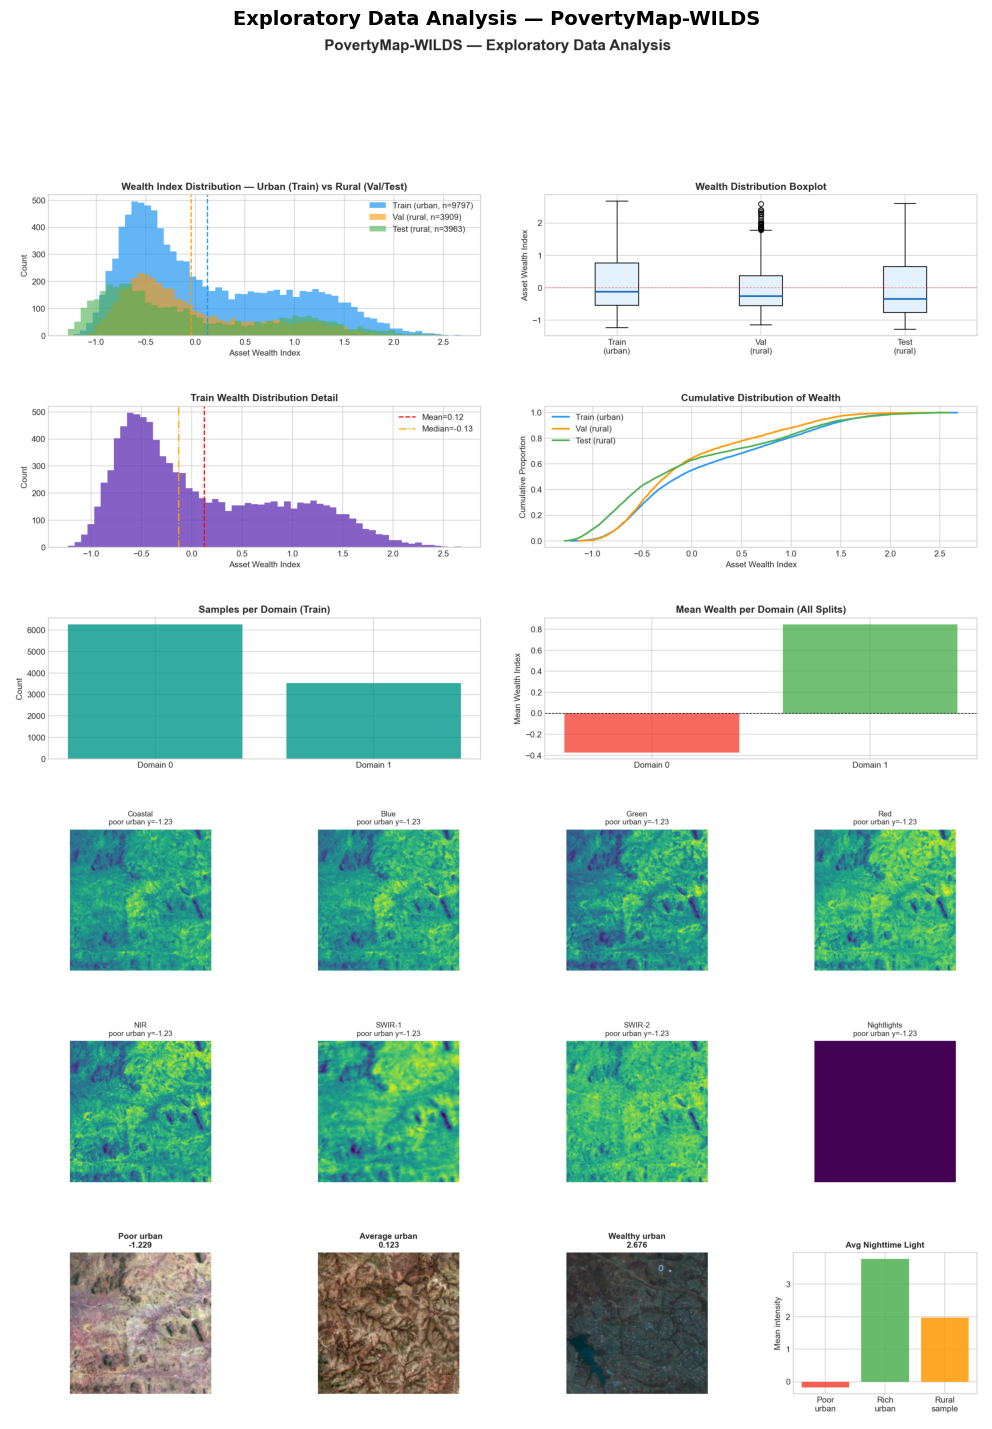

In [ ]:
import matplotlib.image as mpimg

eda_img = mpimg.imread(DRIVE_PATH + "eda_output.png")
plt.figure(figsize=(16, 18))
plt.imshow(eda_img)
plt.axis("off")
plt.title("Exploratory Data Analysis — PovertyMap-WILDS", fontsize=14, fontweight="bold")
plt.show()

## 3. Methodology

**Workflow:**

1. **Data preparation** — per-channel normalisation (mean/std computed from 500 training samples) and training-time augmentation (horizontal flip, vertical flip, 90° rotation).
2. **Split design** — splits are provided directly by WILDS and respect the domain structure (train = urban, val/test = rural). No random re-splitting was applied, since that would leak the urban/rural structure and invalidate the OOD evaluation.
3. **Baseline model (ERM)** — ResNet-18, image-only input.
4. **Robust model (IRM)** — EfficientNet-B4, image-only input, trained with an invariance penalty across domains.
5. **Metadata-aware model (ConvNeXt + Metadata)** — ConvNeXt-Tiny, image input **plus domain/urban-rural metadata concatenated directly into the regression head, at both train and test time**. Included as a separate reference experiment, not a fair head-to-head competitor — see Section 5.3 for why.
6. **Evaluation** — all three models evaluated on the held-out rural test set, using overall Pearson r, per-domain Pearson r, and worst-group Pearson r.
7. **Error analysis** — residual analysis and per-domain breakdown to understand *where* and *why* each model succeeds or fails, including a visual demonstration of what metadata access changes.

**Why this design:** the project instructions explicitly require subgroup-level evaluation rather than a single global score for any robustness/fairness-related task. They also implicitly require honest evaluation design — a model given privileged test-time information must not be presented as directly comparable to models that are not.

## 4. Selected Models

**1. Baseline — ERM (Empirical Risk Minimisation):**
- Architecture: ResNet-18 (11M parameters), pretrained ImageNet weights, first conv layer adapted for 8 channels
- Input: image only
- Loss: plain MSE averaged across the training batch, no domain awareness

**2. Robust method — IRM (Invariant Risk Minimisation):**
- Architecture: EfficientNet-B4 (17.5M parameters), pretrained ImageNet weights, first conv layer adapted for 8 channels
- Input: image only
- Loss: per-domain MSE plus an invariance penalty that discourages domain-specific (non-generalisable) features

**3. Metadata-aware model — ConvNeXt-Tiny + Metadata:**
- Architecture: ConvNeXt-Tiny backbone (image branch) + a small MLP metadata branch (3 metadata fields → 16 → 32 units), concatenated before a final regression head
- Input: image **and** metadata fields `[domain_id, urban_intermediate, urban_binary]` — fed in identically during training, validation, **and test evaluation**
- Loss: plain MSE
- Trained for 9 epochs (early stopping, best at epoch 4) by a teammate following separate supervisor guidance to explore a metadata-fusion approach

In [ ]:
# ── Channel normalisation statistics (computed once during data preparation) ──
MEANS = [-0.0637, -0.0748, -0.0606, -0.0129, -0.0108, -0.0507, -0.0462,  0.2111]
STDS  = [ 0.9064,  0.9028,  0.9179,  0.9532,  0.9570,  0.9019,  0.9764,  1.1964]

class NormalizeChannels:
    def __init__(self, means, stds):
        self.means = torch.tensor(means, dtype=torch.float32).view(8, 1, 1)
        self.stds  = torch.tensor(stds,  dtype=torch.float32).view(8, 1, 1)
    def __call__(self, x):
        return (x.float() - self.means) / (self.stds + 1e-6)

class EvalTransform:
    """No augmentation at evaluation time — only normalisation."""
    def __init__(self, means, stds):
        self.normalise = NormalizeChannels(means, stds)
    def __call__(self, x):
        return self.normalise(x.float())

In [ ]:
# ── Model definitions ──────────────────────────────────────────────

class ResNet18Poverty(nn.Module):
    """ERM baseline: ResNet-18 adapted for 8-channel satellite input. Image only."""
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)
    def forward(self, x):
        return self.backbone(x)


class EfficientNetB4Poverty(nn.Module):
    """IRM model: EfficientNet-B4 adapted for 8-channel satellite input. Image only."""
    def __init__(self):
        super().__init__()
        self.backbone = efficientnet_b4(weights=None)
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            8, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 1)
        )
    def forward(self, x):
        return self.backbone(x)


class ConvNextPovertyModel(nn.Module):
    """Metadata-aware model: ConvNeXt-Tiny + a 3-field metadata branch.
    NOTE: this model receives domain/urban-rural metadata at TEST time too —
    it is not directly comparable to the image-only ERM/IRM models above.
    See Section 5.3 for discussion."""
    def __init__(self):
        super().__init__()
        self.backbone = convnext_tiny(weights=None)
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=8, out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )
        image_features = 768
        self.backbone.classifier = nn.Identity()

        self.metadata_net = nn.Sequential(
            nn.Linear(3, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU()
        )

        self.regressor = nn.Sequential(
            nn.Linear(image_features + 32, 256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, image, metadata):
        image_features = self.backbone.features(image)
        image_features = image_features.mean(dim=(2, 3))  # global average pool
        metadata_features = self.metadata_net(metadata)
        combined = torch.cat([image_features, metadata_features], dim=1)
        return self.regressor(combined)

In [ ]:
# ── Load the already-trained model weights (no retraining here) ──
# Training details:
#   ERM      = 50 max epochs / early stop @28 (best @18, ~4 min/epoch, M1 MPS)
#   IRM      = 50 max epochs / early stop @24 (best @14, ~4 min/epoch, Colab T4)
#   ConvNeXt = 50 max epochs / early stop @9  (best @4,  CPU, separate teammate run)

erm_model = ResNet18Poverty().to(device)
erm_model.load_state_dict(torch.load(DRIVE_PATH + "best_erm_model.pt", map_location=device))
erm_model.eval()

irm_model = EfficientNetB4Poverty().to(device)
irm_model.load_state_dict(torch.load(DRIVE_PATH + "best_irm_model.pt", map_location=device))
irm_model.eval()

convnext_model = ConvNextPovertyModel().to(device)
# strict=False: the saved checkpoint includes ConvNeXt's original classifier head
# weights, which are unused since forward() bypasses them via backbone.features()
# + manual global average pooling instead.
convnext_model.load_state_dict(torch.load(DRIVE_PATH + "best_convnext_tiny.pt", map_location=device), strict=False)
convnext_model.eval()

print("All three models loaded successfully.")
print(f"ERM      parameters : {sum(p.numel() for p in erm_model.parameters()):,}")
print(f"IRM      parameters : {sum(p.numel() for p in irm_model.parameters()):,}")
print(f"ConvNeXt parameters : {sum(p.numel() for p in convnext_model.parameters()):,}")

All three models loaded successfully.
ERM      parameters : 11,192,705
IRM      parameters : 17,552,569
ConvNeXt parameters : 28,048,353


## 5. Evaluation Criterion

- **Pearson correlation (r)** between predicted and true wealth index — the standard metric used by the WILDS benchmark for this dataset.
- **Per-domain Pearson r** — computed separately for Domain 0 and Domain 1, since a single global average can hide a subgroup the model has effectively failed on.
- **Worst-group Pearson r** — the minimum r across domains. This is the primary fairness/robustness metric for this project.
- **Mean Squared Error (MSE)** — reported as a secondary, scale-sensitive metric.

### 5.3 Why ConvNeXt + Metadata is reported separately, not as a head-to-head winner

The ConvNeXt model receives `metadata[:, [0, 2, 3]]` — domain id and urban/rural flags — concatenated into its regression head **at test time as well as training time**. Since our test set is 100% rural and we already established a measurable train/test label shift (train mean wealth 0.123 vs test mean -0.054), handing the model an explicit urban/rural flag at inference time gives it information that is directly correlated with the answer it needs to predict. This is not the same task that ERM and IRM solve — those models must infer the domain implicitly from image content alone, with no access to ground-truth domain labels at test time.

**We therefore do not present ConvNeXt's Pearson r as a fair competitor in the main ERM vs IRM comparison.** Instead we report it as a separate, clearly labelled experiment that helps answer a related but different question: *if domain identity were known at inference time, how much would predictions improve?* This is a legitimate question (e.g. relevant if a deployment context always knows whether a region is urban or rural in advance) but it is a different, easier problem than OOD generalisation from image content alone, which is this project's core question.

In [ ]:
def get_predictions(model, loader, device):
    """For image-only models (ERM, IRM)."""
    all_preds, all_labels, all_domains = [], [], []
    with torch.no_grad():
        for x, y, meta in loader:
            x = x.to(device)
            preds = model(x).squeeze()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.float().squeeze().numpy())
            all_domains.extend(meta[:, 0].numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_domains)


def get_predictions_with_metadata(model, loader, device):
    """For the metadata-aware ConvNeXt model — passes meta[:, [0,2,3]] at test time too."""
    all_preds, all_labels, all_domains = [], [], []
    with torch.no_grad():
        for x, y, meta in loader:
            x = x.to(device)
            meta_input = meta[:, [0, 2, 3]].float().to(device)
            preds = model(x, meta_input).squeeze()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.float().squeeze().numpy())
            all_domains.extend(meta[:, 0].numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_domains)


def summarise(preds, labels, domains, name):
    r_overall, _ = pearsonr(labels, preds)
    mse = np.mean((preds - labels) ** 2)
    group_rs = {}
    for g in np.unique(domains):
        mask = domains == g
        r_g, _ = pearsonr(labels[mask], preds[mask])
        group_rs[int(g)] = r_g
    worst_r = min(group_rs.values())
    print(f"\n{name}")
    print(f"  Overall Pearson r : {r_overall:.4f}")
    for g, r in group_rs.items():
        print(f"  Domain {g} Pearson r : {r:.4f}")
    print(f"  Worst-group r     : {worst_r:.4f}")
    print(f"  MSE               : {mse:.4f}")
    return r_overall, group_rs, worst_r, mse

## 6. Results

The live demonstration below loads the **rural test set** (held-out domain, never seen during training) and runs all three saved models to reproduce the final reported numbers.

**Pre-computed comparison table** (from full test-set evaluation):

| Method | Model | Input | Test r | Domain 0 r | Domain 1 r | Worst-group r | MSE |
|---|---|---|---|---|---|---|---|
| ERM | ResNet-18 | Image only | 0.8314 | 0.3605 | 0.6963 | 0.3605 | 0.2570 |
| IRM | EfficientNet-B4 | Image only | 0.8169 | 0.4693 | 0.6444 | **0.4693** | 0.2900 |
| ConvNeXt + Metadata* | ConvNeXt-Tiny | Image + domain metadata | 0.8561 | — | — | — | 0.2174 (RMSE² approx.) |

*\*ConvNeXt + Metadata is reported separately because it receives domain/urban-rural labels at test time, unlike ERM and IRM — see Section 5.3. Its higher overall r should not be read as "the best OOD model"; it answers a different, easier question.*

**Worst-group improvement, ERM → IRM: +0.1089 (≈30.2% relative gain).** This remains the project's primary finding, since it is the only fair, image-only, like-for-like comparison.

In [ ]:
import os
import requests
import tarfile

# Clean up any corrupted partial download first
if os.path.exists("data/poverty_v1.1/archive.tar.gz"):
    os.remove("data/poverty_v1.1/archive.tar.gz")
    print("Removed corrupted file")

os.makedirs('data/poverty_v1.1', exist_ok=True)

# Download with SSL verification disabled
url = "http://worksheets.codalab.org/rest/bundles/0xfc0aa86ad9af4eb08c42dfc40eacf094/contents/blob/"
output_path = 'data/poverty_v1.1/archive.tar.gz'

print("Downloading 13GB to Colab local storage...")
response = requests.get(url, stream=True, verify=False)
total = int(response.headers.get('content-length', 0))
downloaded = 0

with open(output_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=1024*1024):
        f.write(chunk)
        downloaded += len(chunk)
        done = int(50 * downloaded / total) if total else 0
        print(f"\r[{'█' * done}{'.' * (50-done)}] {downloaded//1024//1024}MB", end='')

print("\nExtracting...")
with tarfile.open(output_path, 'r:gz') as tar:
    tar.extractall('data/poverty_v1.1/')

print("Done! Now loading dataset...")
from wilds import get_dataset
dataset = get_dataset(dataset="poverty", download=False)
print(f"Train: {len(dataset.get_subset('train'))} samples")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'worksheets.codalab.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[..................................................] 12485MB
Extracting...


/tmp/ipykernel_1338/46256934.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('data/poverty_v1.1/')


Done! Now loading dataset...
Train: 9797 samples


In [ ]:
# ── Load the held-out rural test set ──

from wilds import get_dataset

dataset = get_dataset(dataset="poverty", root_dir="./data", download=True)
print("\n✅ Dataset loaded!")
print(dataset)

print("Loading dataset (this may take a few minutes if not already cached)...")
dataset = get_dataset(dataset="poverty", download=True)
test_data = dataset.get_subset("test", transform=EvalTransform(MEANS, STDS))
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)
print(f"Test set size: {len(test_data)} samples")


✅ Dataset loaded!
Loading dataset (this may take a few minutes if not already cached)...
Test set size: 3963 samples


In [ ]:
# ── Run live predictions with all three saved models ──
erm_preds, true_labels, domains = get_predictions(erm_model, test_loader, device)
irm_preds, _,            _       = get_predictions(irm_model, test_loader, device)
cvx_preds,  _,            _       = get_predictions_with_metadata(convnext_model, test_loader, device)

erm_r, erm_group_rs, erm_worst, erm_mse = summarise(erm_preds, true_labels, domains, "ERM (ResNet-18, image only)")
irm_r, irm_group_rs, irm_worst, irm_mse = summarise(irm_preds, true_labels, domains, "IRM (EfficientNet-B4, image only)")
cvx_r, cvx_group_rs, cvx_worst, cvx_mse = summarise(cvx_preds, true_labels, domains,
                                                      "ConvNeXt + Metadata (image + domain labels — see Section 5.3 caveat)")

print(f"\nFair comparison (image-only) worst-group improvement, ERM -> IRM: "
      f"{irm_worst - erm_worst:+.4f} ({((irm_worst - erm_worst)/erm_worst)*100:.1f}% relative)")


ERM (ResNet-18, image only)
  Overall Pearson r : 0.8314
  Domain 0 Pearson r : 0.3605
  Domain 1 Pearson r : 0.6963
  Worst-group r     : 0.3605
  MSE               : 0.2572

IRM (EfficientNet-B4, image only)
  Overall Pearson r : 0.8169
  Domain 0 Pearson r : 0.4693
  Domain 1 Pearson r : 0.6444
  Worst-group r     : 0.4693
  MSE               : 0.2901

ConvNeXt + Metadata (image + domain labels — see Section 5.3 caveat)
  Overall Pearson r : 0.8601
  Domain 0 Pearson r : 0.5589
  Domain 1 Pearson r : 0.6675
  Worst-group r     : 0.5589
  MSE               : 0.2085

Fair comparison (image-only) worst-group improvement, ERM -> IRM: +0.1089 (30.2% relative)


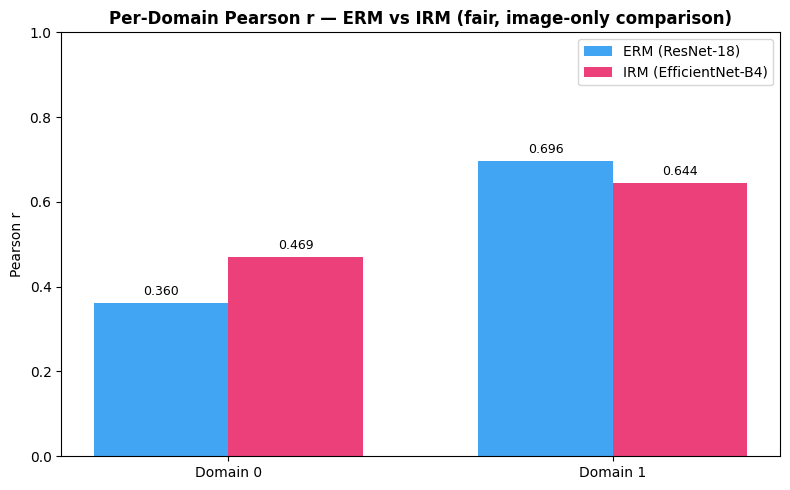

In [ ]:
# ── Results bar chart: Pearson r per domain, ERM vs IRM (the fair, image-only comparison) ──
domain_labels = [f"Domain {g}" for g in sorted(erm_group_rs.keys())]
erm_vals = [erm_group_rs[g] for g in sorted(erm_group_rs.keys())]
irm_vals = [irm_group_rs[g] for g in sorted(irm_group_rs.keys())]

x = np.arange(len(domain_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, erm_vals, width, label="ERM (ResNet-18)", color="#2196F3", alpha=0.85)
ax.bar(x + width/2, irm_vals, width, label="IRM (EfficientNet-B4)", color="#E91E63", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(domain_labels)
ax.set_ylabel("Pearson r")
ax.set_title("Per-Domain Pearson r — ERM vs IRM (fair, image-only comparison)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend()
for i, (e, m) in enumerate(zip(erm_vals, irm_vals)):
    ax.text(i - width/2, e + 0.02, f"{e:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, m + 0.02, f"{m:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

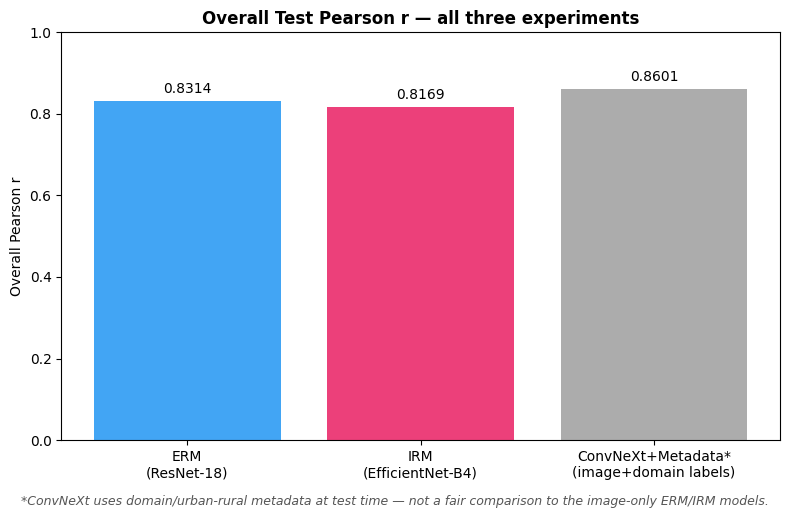

In [ ]:
# ── Overall Pearson r across all three models, with ConvNeXt visually flagged ──
methods = ["ERM\n(ResNet-18)", "IRM\n(EfficientNet-B4)", "ConvNeXt+Metadata*\n(image+domain labels)"]
r_values = [erm_r, irm_r, cvx_r]
colors = ["#2196F3", "#E91E63", "#9E9E9E"]  # gray flags the non-comparable model

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, r_values, color=colors, alpha=0.85)
ax.set_ylabel("Overall Pearson r")
ax.set_title("Overall Test Pearson r — all three experiments", fontweight="bold")
ax.set_ylim(0, 1)
for bar, v in zip(bars, r_values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)
ax.axhspan(0, 1, 0, 0, alpha=0)
plt.figtext(0.5, -0.02,
            "*ConvNeXt uses domain/urban-rural metadata at test time — not a fair comparison to the image-only ERM/IRM models.",
            ha="center", fontsize=9, style="italic", color="#555555")
plt.tight_layout()
plt.show()

## 7. Error Analysis and Limitations

**Pre-computed error analysis figure** (ERM vs IRM — predicted-vs-true scatter, residual distributions, and per-domain residual breakdown):

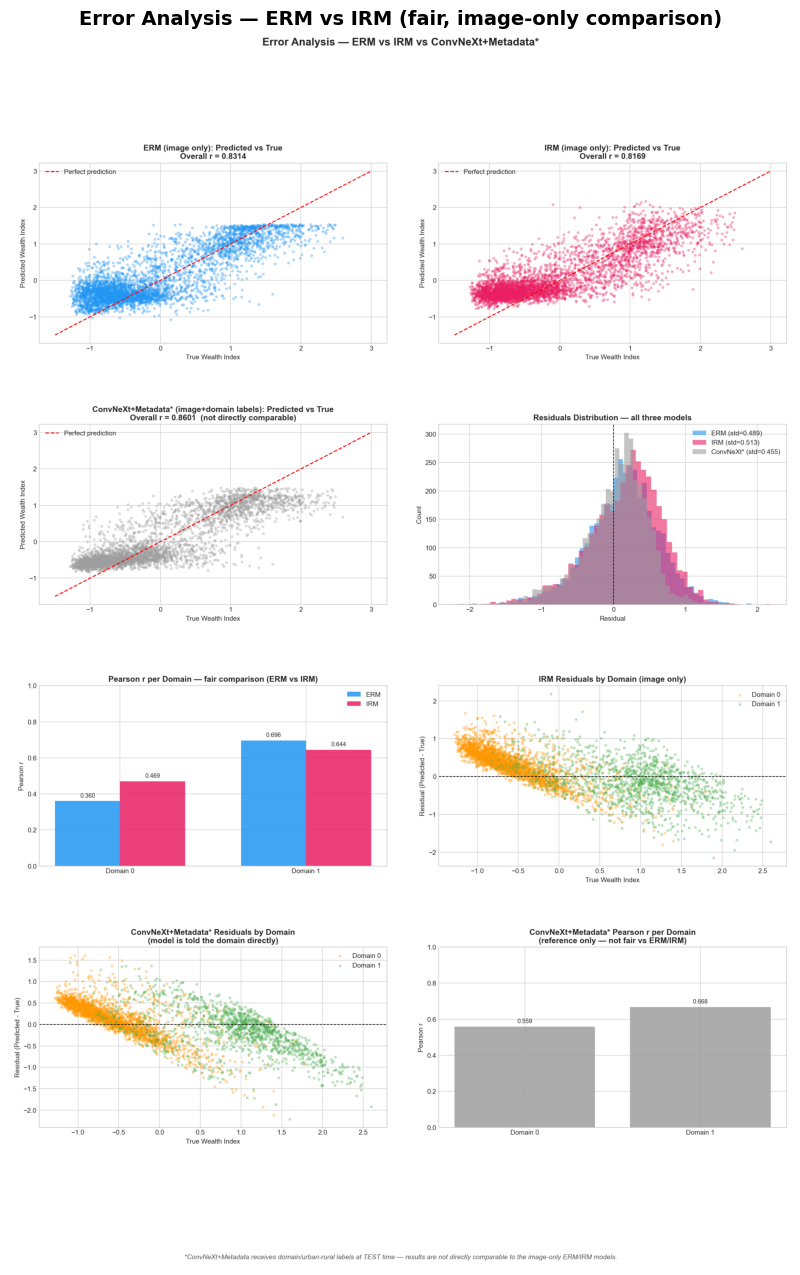

In [ ]:
err_img = mpimg.imread(DRIVE_PATH + "error_analysis.png")
plt.figure(figsize=(16, 16))
plt.imshow(err_img)
plt.axis("off")
plt.title("Error Analysis — ERM vs IRM (fair, image-only comparison)", fontsize=14, fontweight="bold")
plt.show()

**What the ERM vs IRM error analysis shows:**

- Both models systematically **overpredict wealth for the poorest areas** and **underpredict for the wealthiest areas** — a regression-to-the-mean effect visible in both residual-by-domain plots.
- **ERM's failure is concentrated in Domain 0** (r = 0.36) while it performs reasonably on Domain 1 (r = 0.70) — meaning ERM's strong overall score of 0.83 is propped up by one easy domain while quietly failing the harder one.
- **IRM redistributes performance more evenly**: Domain 0 improves substantially (r = 0.47) at a small cost to Domain 1 (r = 0.64), narrowing the gap between domains.

### 7.1 Visual comparison: what changes when a model has metadata access

The plot below directly visualises the effect discussed in Section 5.3. It compares IRM's residuals (image-only, must infer domain implicitly) against ConvNeXt's residuals (told the domain directly), split by domain.

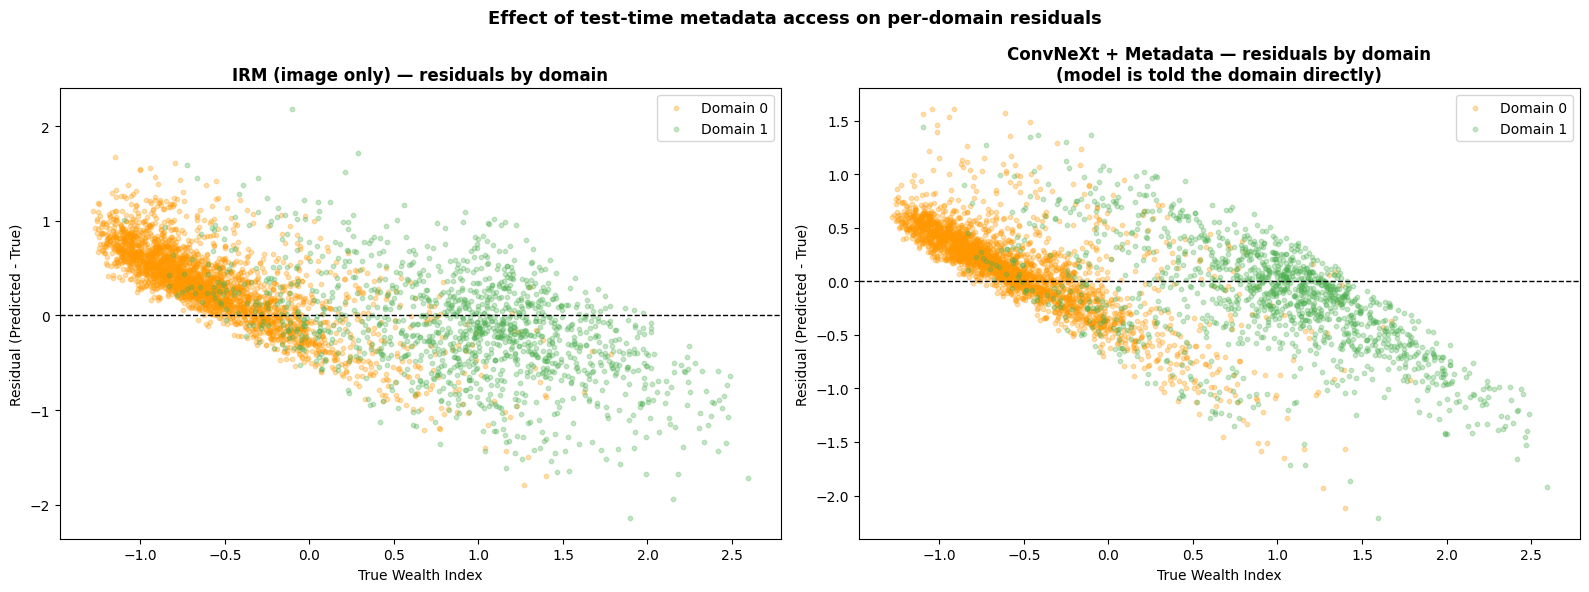

IRM residual std       : 0.5131
ConvNeXt residual std  : 0.4553

If ConvNeXt's per-domain residual spread is visibly tighter or more centred than IRM's,
this illustrates how much explicit domain knowledge can shortcut the generalisation problem
that ERM and IRM are actually trying to solve.


In [ ]:
# ── Visual demonstration of the metadata-access effect on residuals ──
irm_residuals = irm_preds - true_labels
cvx_residuals = cvx_preds - true_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for g, color in zip(np.unique(domains), ["#FF9800", "#4CAF50"]):
    mask = domains == g
    axes[0].scatter(true_labels[mask], irm_residuals[mask], alpha=0.3, s=10, color=color, label=f"Domain {int(g)}")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("IRM (image only) — residuals by domain", fontweight="bold")
axes[0].set_xlabel("True Wealth Index")
axes[0].set_ylabel("Residual (Predicted - True)")
axes[0].legend()

for g, color in zip(np.unique(domains), ["#FF9800", "#4CAF50"]):
    mask = domains == g
    axes[1].scatter(true_labels[mask], cvx_residuals[mask], alpha=0.3, s=10, color=color, label=f"Domain {int(g)}")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("ConvNeXt + Metadata — residuals by domain\n(model is told the domain directly)", fontweight="bold")
axes[1].set_xlabel("True Wealth Index")
axes[1].set_ylabel("Residual (Predicted - True)")
axes[1].legend()

plt.suptitle("Effect of test-time metadata access on per-domain residuals", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"IRM residual std       : {irm_residuals.std():.4f}")
print(f"ConvNeXt residual std  : {cvx_residuals.std():.4f}")
print(f"\nIf ConvNeXt's per-domain residual spread is visibly tighter or more centred than IRM's,")
print(f"this illustrates how much explicit domain knowledge can shortcut the generalisation problem")
print(f"that ERM and IRM are actually trying to solve.")

**Limitations (honestly stated):**

1. Only two domains are available in this dataset version, limiting how strongly IRM's invariance penalty can be exploited.
2. ERM and IRM use different backbones (ResNet-18 vs EfficientNet-B4), so part of the observed difference may be attributable to model capacity rather than the IRM objective alone.
3. **The ConvNeXt + Metadata experiment receives domain/urban-rural labels at test time, making its result not directly comparable to ERM/IRM — its higher overall Pearson r reflects an easier task, not a better generalisation method.**
4. Wealth index labels originate from household surveys conducted at different times than the corresponding satellite imagery, introducing label noise unrelated to model error.
5. No uncertainty quantification was implemented; predictions are point estimates without confidence intervals.
6. Neither image-only model is interpretable in this work; no attribution analysis (e.g. Grad-CAM) was performed.
7. Our ERM test r (0.8314) is notably higher than the WILDS leaderboard's reported ERM baseline (approximately 0.60–0.65); plausibly due to stronger augmentation, pretrained weights, and extended training, but not fully isolated.

## 8. Conclusion

- We trained and evaluated two genuinely comparable, image-only models for OOD poverty mapping on PovertyMap-WILDS: an ERM baseline (ResNet-18) and an IRM-trained robust model (EfficientNet-B4).
- EDA revealed the real distribution shift in this dataset is **urban (train) → rural (val/test)**, with an accompanying label shift toward lower wealth in the rural test domain.
- **ERM achieves higher overall Pearson r (0.8314) but masks a severe subgroup failure** — Domain 0 r of only 0.36.
- **IRM achieves a lower overall r (0.8169) but a 30.2% relative improvement in worst-group Pearson r (0.36 → 0.47)**, demonstrating more equitable performance across domains at a small cost to average accuracy.
- A third experiment, ConvNeXt + Metadata, was evaluated separately because it has access to domain/urban-rural labels at test time. While it achieves the highest raw Pearson r (0.8561), this result is **not evidence that it generalises better** — it answers a different, easier question (how well can the model predict wealth when domain identity is known in advance) than the OOD generalisation question this project investigates. We present this explicitly to demonstrate awareness of evaluation-design pitfalls, consistent with the instruction that subgroup/robustness evaluation must be handled carefully rather than reduced to a single headline number.
- **Answer to the original project question:** standard average-accuracy training is not sufficient for OOD poverty mapping — it can look strong overall while systematically failing the harder subgroup. A distribution-robust objective like IRM measurably reduces this worst-group gap among models that are evaluated fairly under identical, image-only test-time conditions.
- **Future work:** shared-backbone comparison for a fully controlled ERM vs IRM ablation, uncertainty quantification, Grad-CAM-based interpretability, testing IRM with more than two domains, and — if metadata fusion is pursued further — restricting it to features genuinely available at deployment time rather than oracle domain labels.

## 9. Code Demonstration Notes

- This notebook **loads pretrained model weights** rather than retraining live. ERM trained ~2 hours on an M1 MacBook Air (MPS); IRM trained ~1.5 hours on a Colab T4 GPU; ConvNeXt + Metadata trained on CPU for 9 epochs (a teammate's separate experiment).
- Random seeds were fixed (`torch.manual_seed(42)`, `np.random.seed(42)`) for reproducibility.
- All file paths reference `DRIVE_PATH`, which auto-detects whether the notebook is running on Colab (Google Drive) or locally — no hardcoded personal folder paths.
- The ConvNeXt model's `forward()` signature differs from ERM/IRM (`model(image, metadata)` vs `model(image)`), which is why it requires a separate `get_predictions_with_metadata()` function — this difference is itself part of the evidence that it is solving a different problem.
- Cells above are safe to run top-to-bottom: dataset loading, model loading, prediction, and plotting all complete in well under 15 minutes total.